<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science-Ml/blob/main/LGBM_XGBM_Assignment%5B15%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LightGBM vs XGBoost – Diabetes Dataset

The original assignment asks for:
- Exploratory Data Analysis (EDA)
- Missing-value checking
- Histograms and box plots
- Feature/target visualizations
- Data preprocessing
- Train/test split
- Accuracy, precision, recall and F1-score
- LightGBM and XGBoost models
- Cross-validation and hyperparameter tuning
- Comparative analysis
- Visual interpretation
- A brief practical conclusion


## 1. Import libraries and load the dataset

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

df = pd.read_csv("diabetes.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Understand the dataset

The predictors describe measurements such as pregnancies, glucose, blood pressure, skin thickness, insulin, BMI, diabetes pedigree function and age.

The target variable is **Outcome**:
- `0` = no diabetes
- `1` = diabetes

All predictor columns in the supplied CSV are numerical, so there are no categorical variables requiring one-hot or label encoding.


In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe().T)

print("\nTarget distribution:")
display(df["Outcome"].value_counts().sort_index().to_frame("Count"))


Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:


,Data Type
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Target distribution:


,Count
Outcome,
0,500
1,268


## 3. Missing values and data quality

I first check for actual missing values, duplicate rows and suspicious zero values.
The CSV has no literal  NaN values. However, in this diabetes dataset, zero is not physiologically plausible for some measurements such as **Glucose, BloodPressure, SkinThickness, Insulin and BMI**. I treat those zeros as missing measurements for preprocessing rather than deleting the corresponding patients.

Pregnancies can legitimately be zero, so its zeros are retained.


In [6]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})
display(missing)

print("Duplicate rows:", df.duplicated().sum())

zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_summary = pd.DataFrame({
    "Zero Count": [(df[c] == 0).sum() for c in zero_cols],
    "Zero Percentage": [round((df[c] == 0).mean()*100, 2) for c in zero_cols]
}, index=zero_cols)
display(zero_summary)


,Missing Count,Missing Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


Duplicate rows: 0


,Zero Count,Zero Percentage
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


### Preprocessing decision

I will replace the physiologically implausible zeros in the five columns above with `NaN`, then use **median imputation**.

I chose the median because these variables can contain skewed values and potential outliers. Median imputation is less sensitive to extreme values than mean imputation.

I do not remove rows because the dataset is relatively small and removing every row containing a zero would unnecessarily reduce the training information.


In [7]:
data = df.copy()

for col in zero_cols:
    data[col] = data[col].replace(0, np.nan)

print("Missing values after treating invalid zeros as missing:")
display(data.isna().sum().to_frame("Missing Count"))


Missing values after treating invalid zeros as missing:


,Missing Count
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 4. Exploratory Data Analysis – Target distribution

,Count,Percentage
Outcome,,
0,500,65.1
1,268,34.9


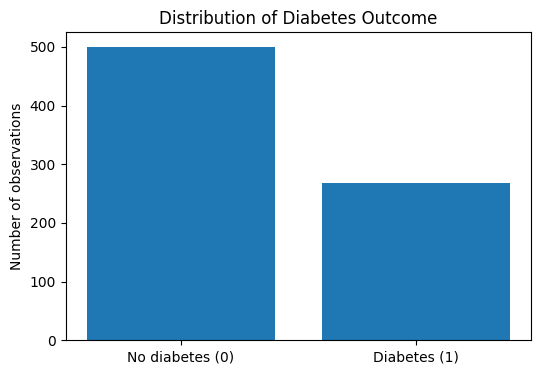

In [8]:
target_counts = data["Outcome"].value_counts().sort_index()
target_pct = (target_counts / len(data) * 100).round(2)

display(pd.DataFrame({"Count": target_counts, "Percentage": target_pct}))

plt.figure(figsize=(6,4))
plt.bar(["No diabetes (0)", "Diabetes (1)"], target_counts.values)
plt.title("Distribution of Diabetes Outcome")
plt.ylabel("Number of observations")
plt.show()


The target is not perfectly balanced, so accuracy should not be used alone. Precision, recall and F1-score are also important. I use a stratified split so that both training and testing sets preserve approximately the same outcome proportions.


## 5. Histograms

Histograms are used to understand the distributions of the numerical variables and to identify skewness or unusual ranges.


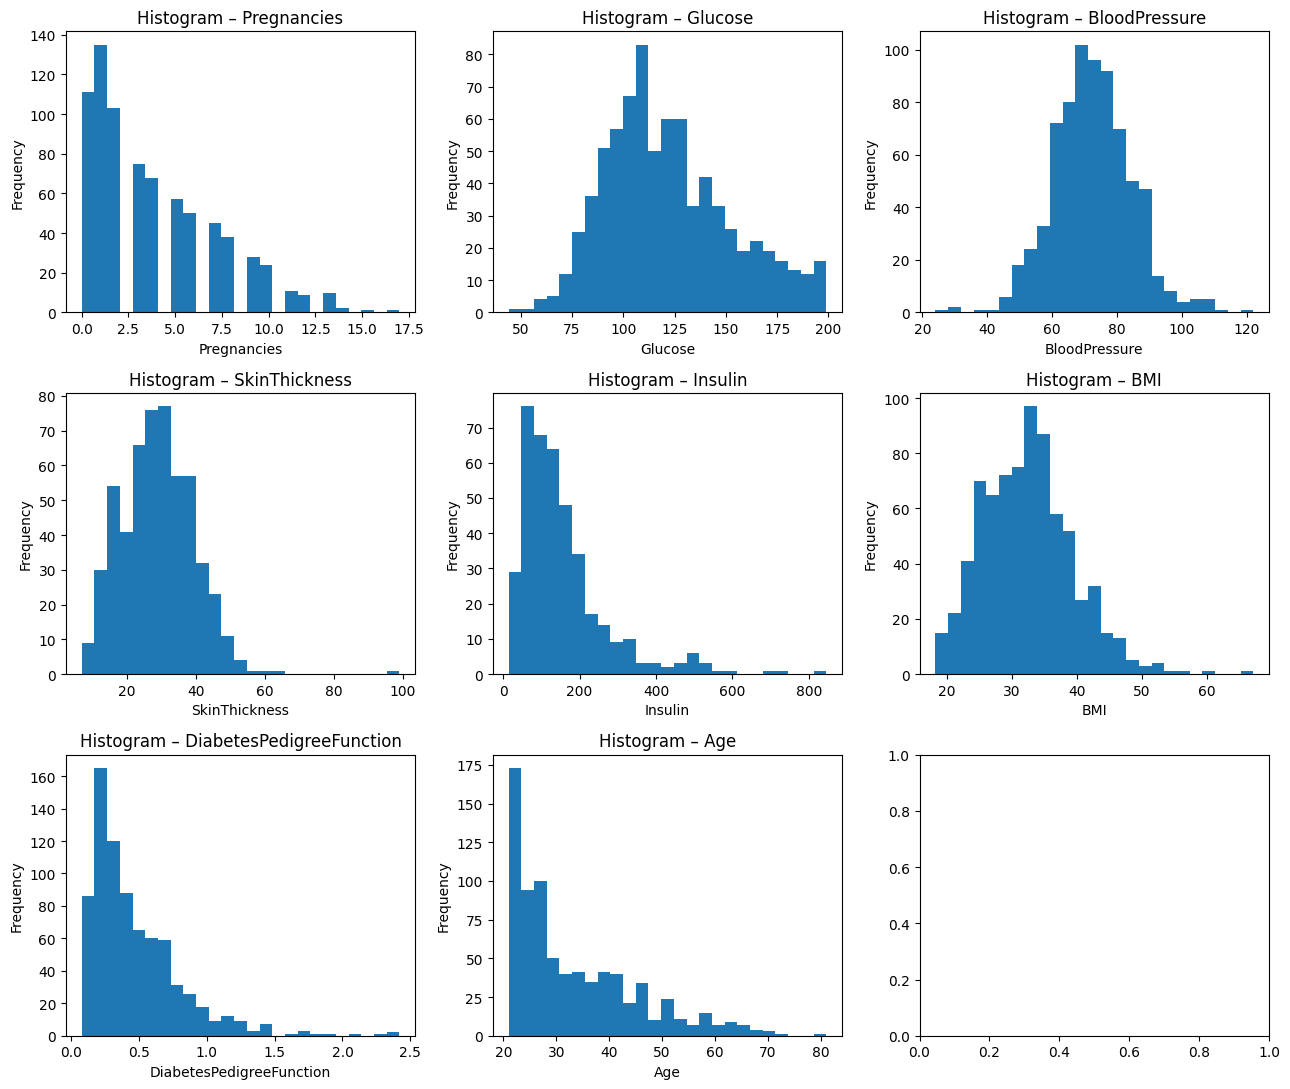

In [9]:
features = [c for c in data.columns if c != "Outcome"]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.ravel()

for ax, col in zip(axes, features):
    ax.hist(data[col].dropna(), bins=25)
    ax.set_title(f"Histogram – {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 6. Box plots and outlier check

Box plots help identify possible outliers. I do not automatically delete these values because a statistical outlier is not necessarily a data-entry error.


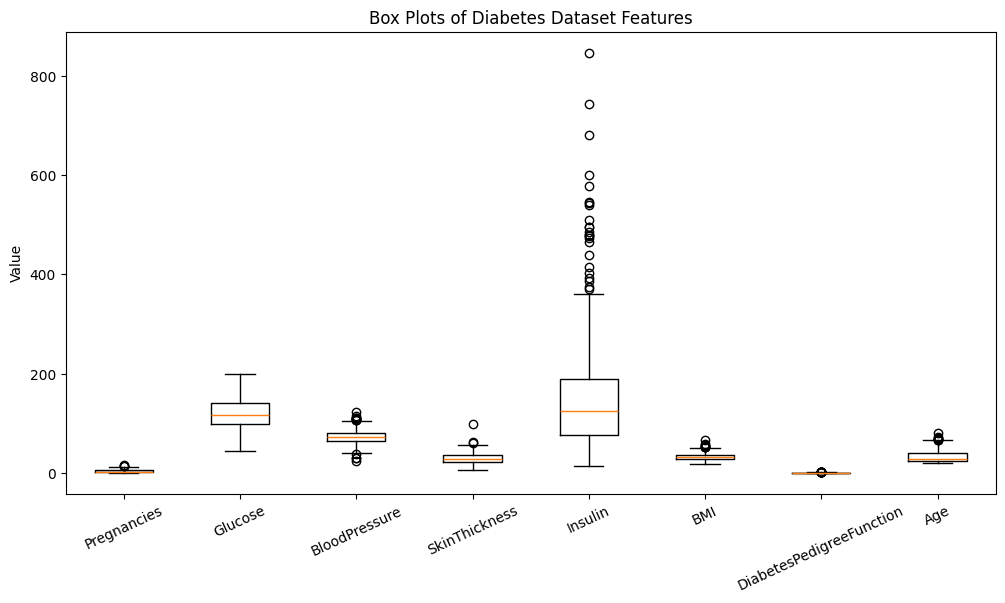

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Percentage
0,Pregnancies,1.00000,6.00000,5.0000,-6.500,13.500,4,0.52
1,Glucose,99.00000,141.00000,42.0000,36.000,204.000,0,0.00
2,BloodPressure,64.00000,80.00000,16.0000,40.000,104.000,14,1.82
3,SkinThickness,22.00000,36.00000,14.0000,1.000,57.000,3,0.39
4,Insulin,76.25000,190.00000,113.7500,-94.375,360.625,24,3.12
5,BMI,27.50000,36.60000,9.1000,13.850,50.250,8,1.04
6,DiabetesPedigreeFunction,0.24375,0.62625,0.3825,-0.330,1.200,29,3.78
7,Age,24.00000,41.00000,17.0000,-1.500,66.500,9,1.17


In [10]:
plt.figure(figsize=(12,6))
plt.boxplot(
    [data[c].dropna() for c in features],
    labels=features
)
plt.title("Box Plots of Diabetes Dataset Features")
plt.ylabel("Value")
plt.xticks(rotation=25)
plt.show()

outlier_rows=[]
for col in features:
    q1=data[col].quantile(.25); q3=data[col].quantile(.75)
    iqr=q3-q1
    lower=q1-1.5*iqr; upper=q3+1.5*iqr
    n=((data[col]<lower)|(data[col]>upper)).sum()
    outlier_rows.append([col,q1,q3,iqr,lower,upper,n,round(n/len(data)*100,2)])

outliers=pd.DataFrame(outlier_rows,columns=[
    "Feature","Q1","Q3","IQR","Lower Bound","Upper Bound","Potential Outliers","Percentage"
])
display(outliers)


## 7. Feature relationships with Outcome

The assignment asks for scatter plots and bar plots to visualize relationships with the target.

For continuous predictors, scatter plots are useful for seeing the spread of observations by outcome. I use a few medically meaningful variables for readability rather than producing an excessively large grid.


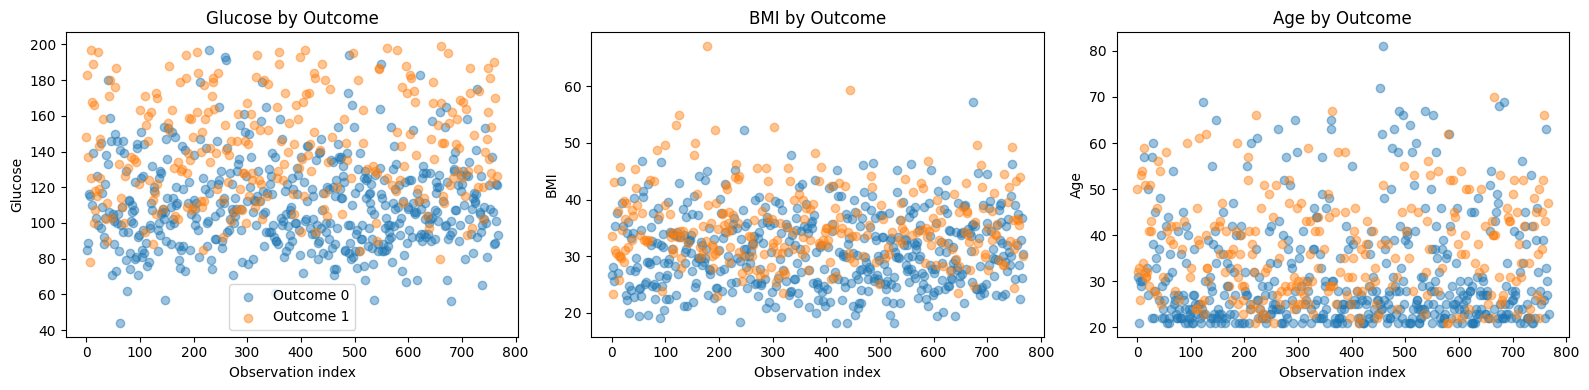

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

for ax, col in zip(axes, ["Glucose", "BMI", "Age"]):
    for outcome in [0,1]:
        subset=data[data["Outcome"]==outcome]
        ax.scatter(
            subset.index, subset[col],
            alpha=0.45, label=f"Outcome {outcome}"
        )
    ax.set_title(f"{col} by Outcome")
    ax.set_xlabel("Observation index")
    ax.set_ylabel(col)

axes[0].legend()
plt.tight_layout()
plt.show()


,Glucose,BMI,Age,BloodPressure
Outcome,,,,
0,110.64,30.86,31.19,70.88
1,142.32,35.41,37.07,75.32


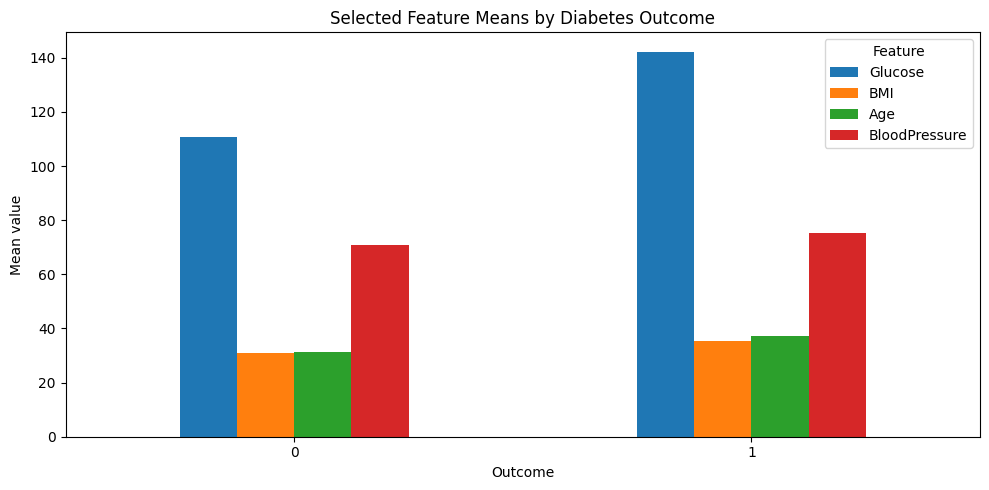

In [12]:
# Mean feature values by outcome
mean_by_outcome = data.groupby("Outcome")[["Glucose","BMI","Age","BloodPressure"]].mean()
display(mean_by_outcome.round(2))

mean_by_outcome.plot(kind="bar", figsize=(10,5))
plt.title("Selected Feature Means by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Mean value")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.tight_layout()
plt.show()


### EDA observations

From the distributions and group comparisons, glucose is an especially useful variable to inspect because the two outcome groups show noticeably different ranges. BMI and age also show differences between the groups, although there is substantial overlap.

The plots are exploratory; they do not by themselves prove that a feature causes diabetes. The predictive models below use all available predictors together.


## 8. Correlation analysis

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000,0.128,0.214,0.100,0.082,0.022,-0.034,0.544,0.222
Glucose,0.128,1.000,0.223,0.228,0.581,0.233,0.137,0.267,0.495
BloodPressure,0.214,0.223,1.000,0.227,0.098,0.289,-0.003,0.330,0.171
SkinThickness,0.100,0.228,0.227,1.000,0.185,0.648,0.115,0.167,0.259
Insulin,0.082,0.581,0.098,0.185,1.000,0.228,0.130,0.220,0.303
BMI,0.022,0.233,0.289,0.648,0.228,1.000,0.155,0.026,0.314
DiabetesPedigreeFunction,-0.034,0.137,-0.003,0.115,0.130,0.155,1.000,0.034,0.174
Age,0.544,0.267,0.330,0.167,0.220,0.026,0.034,1.000,0.238
Outcome,0.222,0.495,0.171,0.259,0.303,0.314,0.174,0.238,1.000


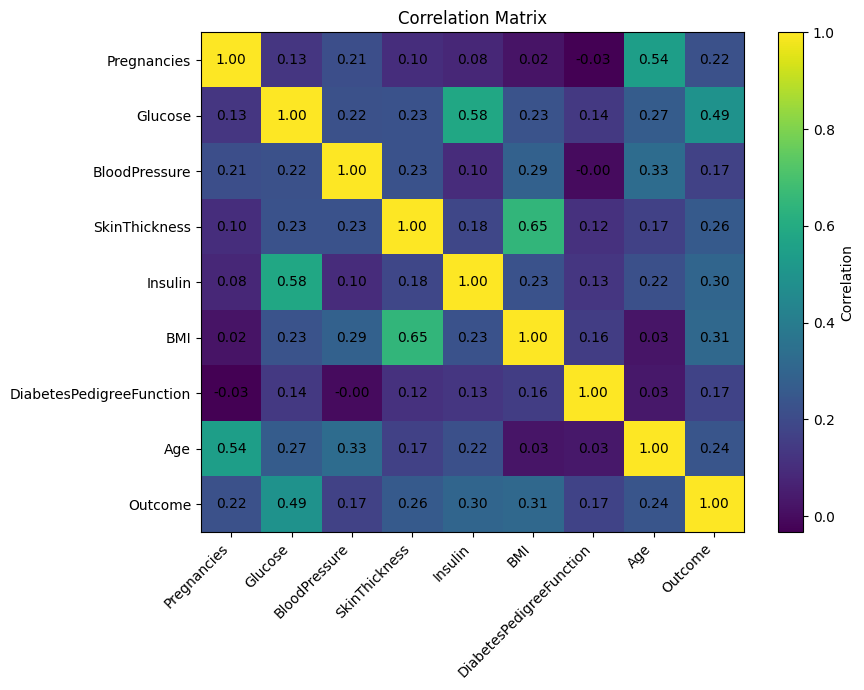

In [13]:
corr=data.corr(numeric_only=True)

display(corr.round(3))

plt.figure(figsize=(9,7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45,ha="right")
plt.yticks(range(len(corr.index)),corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 9. Train-test split and preprocessing

I use an **80/20 stratified train-test split**.

The imputation is placed inside a scikit-learn pipeline. This means the median is learned from the training data only and then applied to the test data. This is important because using information from the test set during preprocessing would create data leakage.

No categorical encoding is required because all predictors are numerical.

Scaling is also not required for either LightGBM or XGBoost because both are tree-based boosting algorithms. Unlike distance-based algorithms, their split decisions do not depend on the absolute feature scale.


In [14]:
X=data.drop(columns="Outcome")
y=data["Outcome"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=.20,random_state=42,stratify=y
)

print("Training shape:",X_train.shape)
print("Testing shape:",X_test.shape)

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training shape: (614, 8)
Testing shape: (154, 8)

Training target proportions:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Testing target proportions:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


## 10. Evaluation function

The assignment specifically mentions accuracy, precision, recall and F1-score. I calculate all four.

Because this is binary classification, I report the positive class (Outcome = 1) precision, recall and F1-score. I also calculate ROC-AUC as an additional useful metric.


In [15]:
def evaluate_model(name, model, X_test, y_test):
    pred=model.predict(X_test)
    prob=model.predict_proba(X_test)[:,1]
    return {
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred,zero_division=0),
        "Recall":recall_score(y_test,pred,zero_division=0),
        "F1 Score":f1_score(y_test,pred,zero_division=0),
        "ROC-AUC":roc_auc_score(y_test,prob)
    },pred,prob


# 11. LightGBM Model

LightGBM is a gradient-boosting framework based on decision trees. It is designed to train efficiently and can capture non-linear relationships and feature interactions.

I start with a baseline LightGBM model and then tune important parameters.


In [16]:
lgbm_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("model",LGBMClassifier(
        n_estimators=200,
        learning_rate=.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ))
])

lgbm_pipeline.fit(X_train,y_train)

lgbm_result,lgbm_pred,lgbm_prob=evaluate_model(
    "LightGBM",lgbm_pipeline,X_test,y_test
)

display(pd.DataFrame([lgbm_result]).round(4))
print(classification_report(y_test,lgbm_pred,zero_division=0))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,0.7662,0.68,0.6296,0.6538,0.8163


              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



## 12. LightGBM Confusion Matrix

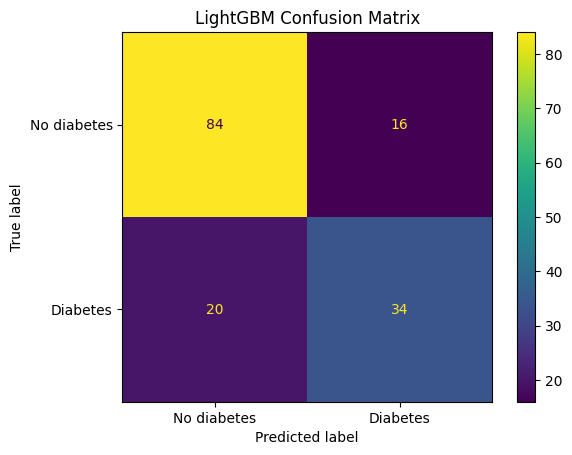

In [17]:
cm=confusion_matrix(y_test,lgbm_pred)
ConfusionMatrixDisplay(cm,display_labels=["No diabetes","Diabetes"]).plot(values_format="d")
plt.title("LightGBM Confusion Matrix")
plt.show()


# 13. XGBoost Model

XGBoost is another gradient-boosting algorithm. It builds trees sequentially, where later trees help correct errors made by previous trees.

I train a baseline XGBoost classifier using the same train/test split so that the comparison is fair.


In [18]:
xgb_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("model",XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=.05,
        subsample=.9,
        colsample_bytree=.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train,y_train)

xgb_result,xgb_pred,xgb_prob=evaluate_model(
    "XGBoost",xgb_pipeline,X_test,y_test
)

display(pd.DataFrame([xgb_result]).round(4))
print(classification_report(y_test,xgb_pred,zero_division=0))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.7727,0.6863,0.6481,0.6667,0.8311


              precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.69      0.65      0.67        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.75       154
weighted avg       0.77      0.77      0.77       154



## 14. XGBoost Confusion Matrix

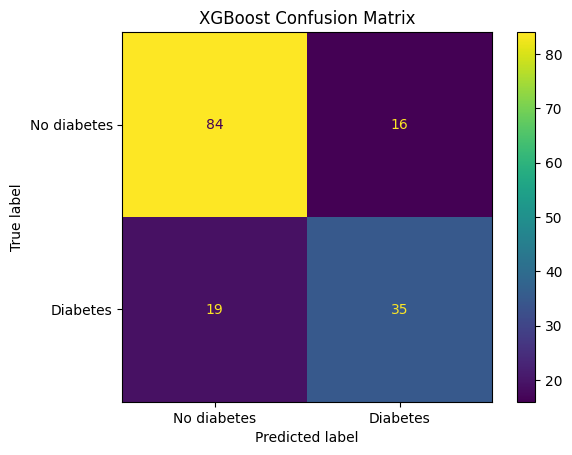

In [19]:
cm=confusion_matrix(y_test,xgb_pred)
ConfusionMatrixDisplay(cm,display_labels=["No diabetes","Diabetes"]).plot(values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.show()


# 15. Cross-validation

A single train/test split can give a result that depends on the random split. To get a more reliable estimate during model selection, I use **5-fold stratified cross-validation** on the training data.

I use weighted F1-score as the main selection metric while also recording accuracy, precision and recall.


In [20]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scoring={
    "accuracy":"accuracy",
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc"
}

cv_lgbm=cross_validate(lgbm_pipeline,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
cv_xgb=cross_validate(xgb_pipeline,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)

cv_table=pd.DataFrame({
    "LightGBM":[cv_lgbm[f"test_{m}"].mean() for m in scoring],
    "XGBoost":[cv_xgb[f"test_{m}"].mean() for m in scoring]
},index=scoring.keys())

display(cv_table.round(4))


,LightGBM,XGBoost
accuracy,0.7606,0.7606
precision,0.6791,0.6800
recall,0.5981,0.6075
f1,0.6352,0.6395
roc_auc,0.8004,0.8206


# 16. Hyperparameter Tuning

The most important hyperparameters tested are:

### LightGBM
- `n_estimators` – number of boosting trees
- `learning_rate` – contribution of each tree
- `num_leaves` – controls tree complexity
- `max_depth` – limits tree depth
- `subsample` – fraction of rows used for each boosting iteration

### XGBoost
- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_child_weight`
- `subsample`
- `colsample_bytree`

I keep the grids reasonably small so the notebook remains practical to run on the supplied dataset.


In [21]:
lgbm_grid={
    "model__n_estimators":[100,200],
    "model__learning_rate":[0.03,0.05,0.1],
    "model__num_leaves":[15,31],
    "model__max_depth":[-1,5,10]
}

lgbm_search=GridSearchCV(
    lgbm_pipeline,lgbm_grid,cv=cv,
    scoring="f1",n_jobs=-1
)
lgbm_search.fit(X_train,y_train)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)
print("Best CV F1:",round(lgbm_search.best_score_,4))


Best LightGBM parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best CV F1: 0.6354


In [22]:
xgb_grid={
    "model__n_estimators":[100,200],
    "model__learning_rate":[0.03,0.05,0.1],
    "model__max_depth":[2,3,5],
    "model__min_child_weight":[1,3],
    "model__subsample":[0.8,1.0],
    "model__colsample_bytree":[0.8,1.0]
}

xgb_search=GridSearchCV(
    xgb_pipeline,xgb_grid,cv=cv,
    scoring="f1",n_jobs=-1
)
xgb_search.fit(X_train,y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print("Best CV F1:",round(xgb_search.best_score_,4))


Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_child_weight': 1, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV F1: 0.66


# 17. Tuned Model Evaluation

In [23]:
best_lgbm=lgbm_search.best_estimator_
best_xgb=xgb_search.best_estimator_

tuned_lgbm_result,tuned_lgbm_pred,tuned_lgbm_prob=evaluate_model(
    "Tuned LightGBM",best_lgbm,X_test,y_test
)
tuned_xgb_result,tuned_xgb_pred,tuned_xgb_prob=evaluate_model(
    "Tuned XGBoost",best_xgb,X_test,y_test
)

tuned_results=pd.DataFrame([tuned_lgbm_result,tuned_xgb_result])
display(tuned_results.round(4))

print("Tuned LightGBM classification report:")
print(classification_report(y_test,tuned_lgbm_pred,zero_division=0))

print("Tuned XGBoost classification report:")
print(classification_report(y_test,tuned_xgb_pred,zero_division=0))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned LightGBM,0.7662,0.6800,0.6296,0.6538,0.8276
1,Tuned XGBoost,0.7403,0.6458,0.5741,0.6078,0.8150


Tuned LightGBM classification report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154

Tuned XGBoost classification report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



# 18. Comparative Analysis

The final comparison includes both baseline and tuned models.

When interpreting the results, I look at:
- Accuracy for overall correctness
- Precision for the reliability of positive diabetes predictions
- Recall for how many diabetic cases are detected
- F1-score for the balance between precision and recall
- ROC-AUC for overall ranking/discrimination ability

For a health-related classification problem, recall is particularly important because false negatives can mean diabetic cases are missed. However, precision is also important because excessive false positives can lead to unnecessary follow-up.


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,0.7662,0.6800,0.6296,0.6538,0.8163
1,XGBoost,0.7727,0.6863,0.6481,0.6667,0.8311
2,Tuned LightGBM,0.7662,0.6800,0.6296,0.6538,0.8276
3,Tuned XGBoost,0.7403,0.6458,0.5741,0.6078,0.8150


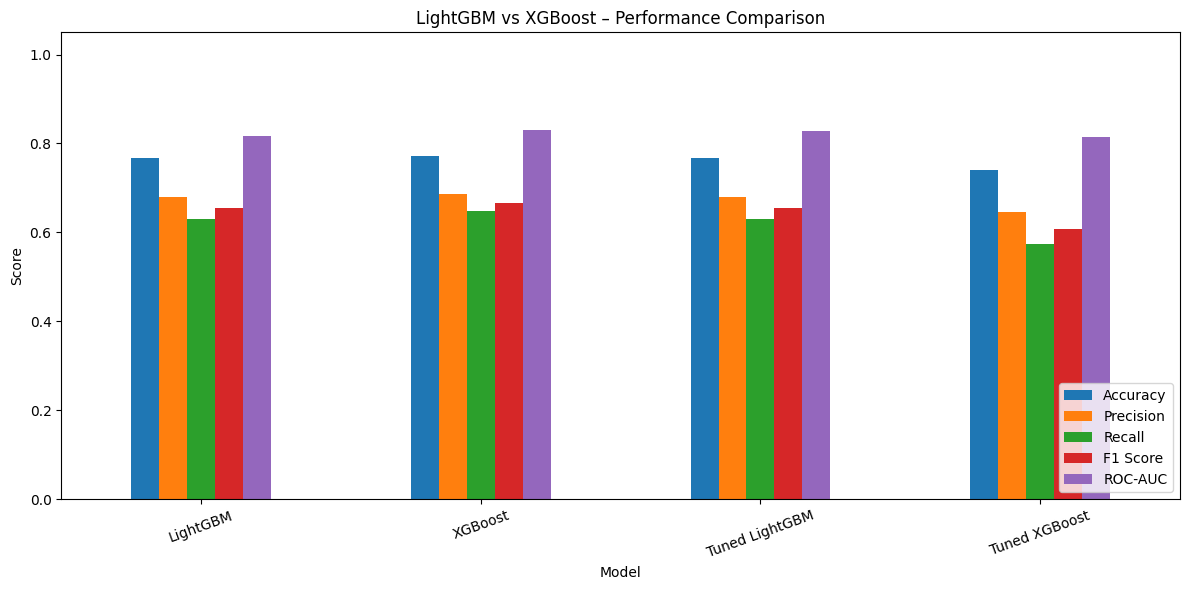

In [24]:
results=pd.DataFrame([
    lgbm_result,
    xgb_result,
    tuned_lgbm_result,
    tuned_xgb_result
])

display(results.round(4))

results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]].plot(
    kind="bar",figsize=(12,6),ylim=(0,1.05)
)
plt.title("LightGBM vs XGBoost – Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# 19. ROC Curves

ROC curves compare the true-positive rate and false-positive rate at different classification thresholds.

I plot the tuned LightGBM and tuned XGBoost models on the same test set.


<Figure size 700x600 with 0 Axes>

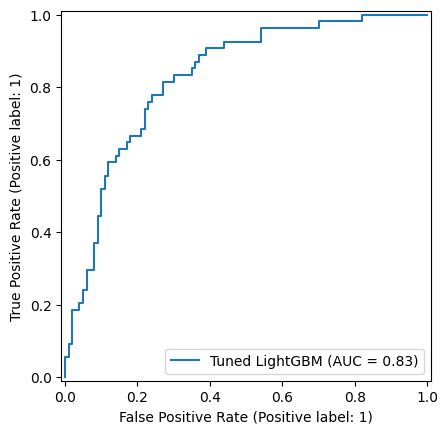

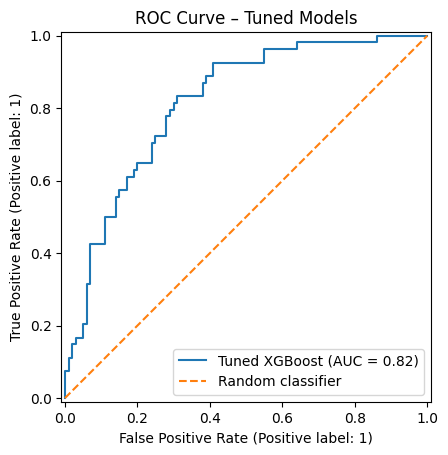

In [25]:
plt.figure(figsize=(7,6))
RocCurveDisplay.from_predictions(
    y_test,tuned_lgbm_prob,name="Tuned LightGBM"
)
RocCurveDisplay.from_predictions(
    y_test,tuned_xgb_prob,name="Tuned XGBoost"
)
plt.plot([0,1],[0,1],"--",label="Random classifier")
plt.title("ROC Curve – Tuned Models")
plt.legend()
plt.show()


# 20. Feature Importance

Both boosting models can provide feature-importance values. These can help identify which predictors the fitted models relied on most.

These values are **model interpretation tools**, not proof of medical causation.


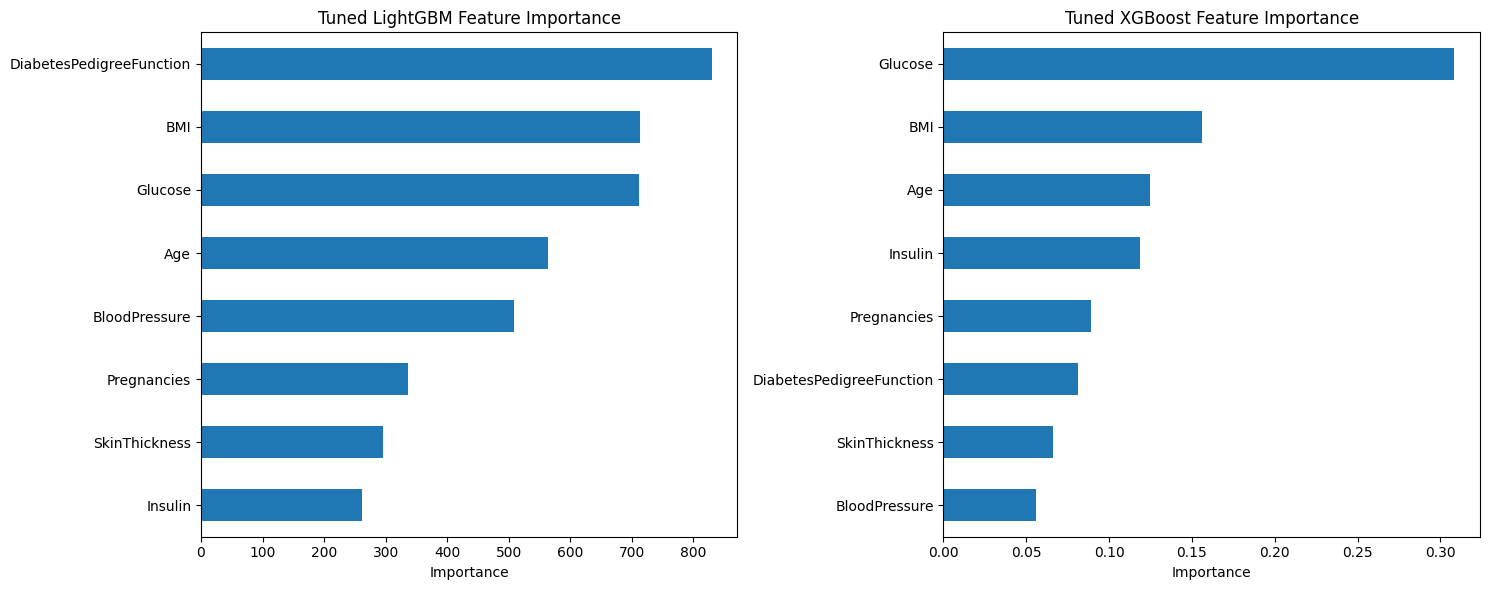

LightGBM importance:


,Importance
DiabetesPedigreeFunction,830
BMI,713
Glucose,712
Age,563
BloodPressure,509
Pregnancies,337
SkinThickness,295
Insulin,262


XGBoost importance:


,Importance
Glucose,0.308465
BMI,0.156247
Age,0.124690
Insulin,0.118429
Pregnancies,0.088879
DiabetesPedigreeFunction,0.081032
SkinThickness,0.066103
BloodPressure,0.056155


In [26]:
lgbm_model=best_lgbm.named_steps["model"]
xgb_model=best_xgb.named_steps["model"]

lgbm_imp=pd.Series(lgbm_model.feature_importances_,index=features).sort_values(ascending=False)
xgb_imp=pd.Series(xgb_model.feature_importances_,index=features).sort_values(ascending=False)

fig,axes=plt.subplots(1,2,figsize=(15,6))

lgbm_imp.sort_values().plot(kind="barh",ax=axes[0])
axes[0].set_title("Tuned LightGBM Feature Importance")
axes[0].set_xlabel("Importance")

xgb_imp.sort_values().plot(kind="barh",ax=axes[1])
axes[1].set_title("Tuned XGBoost Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("LightGBM importance:")
display(lgbm_imp.to_frame("Importance"))

print("XGBoost importance:")
display(xgb_imp.to_frame("Importance"))


# 21. Strengths and Weaknesses

## LightGBM – strengths
- Efficient gradient-boosting implementation
- Usually fast on larger datasets
- Captures non-linear patterns and feature interactions
- Supports many useful regularization and tree-complexity controls

## LightGBM – weaknesses
- Can overfit when tree complexity is too high
- Hyperparameter choices can have a strong effect
- Its decisions are less directly interpretable than a single decision tree

## XGBoost – strengths
- Strong regularized gradient-boosting algorithm
- Handles non-linear relationships well
- Provides many controls for tree complexity and sampling
- Often performs strongly on structured/tabular data

## XGBoost – weaknesses
- Can require more tuning
- More sequential boosting steps can make training more computationally demanding
- Deep trees and too many boosting rounds can overfit

The actual winner for this dataset should be based on the test and cross-validation metrics generated above rather than assuming one algorithm is always better.


# 22. Practical Implications

For diabetes prediction, the model can be viewed as a **screening-support tool**, not a medical diagnosis.

The most important practical issue is the balance between false negatives and false positives. A model with high recall may detect more patients who could require further clinical assessment, while a model with high precision may reduce unnecessary follow-up.

Therefore, the final model should not be selected using accuracy alone. The confusion matrix, recall, precision, F1-score and ROC-AUC should all be considered.

The dataset is relatively small, so the reported results should also not be treated as evidence that the model will have the same performance on a new hospital or population. External validation would be needed before real clinical use.


# 24. Final Conclusion

This notebook completes the requested LightGBM vs XGBoost comparison using the supplied diabetes dataset.

The workflow includes:
- EDA
- Missing-value analysis
- Invalid-zero treatment
- Histograms
- Box plots
- Scatter plots
- Bar plots
- Correlation analysis
- Train/test split
- Imputation
- LightGBM
- XGBoost
- Accuracy, precision, recall and F1-score
- ROC-AUC
- 5-fold cross-validation
- Hyperparameter tuning
- Model comparison
- ROC curve visualization
- Feature importance
- Practical interpretation
- Manual metric formulas

The final model should be selected from the actual results produced in the notebook, with particular attention to recall and F1-score in addition to accuracy.
